In [1]:
# magics: ensures that any changes to the modules loaded below will be re-loaded automatically
%load_ext autoreload
%autoreload 2

# load general packages
import numpy as np
import time
import copy

import matplotlib.pyplot as plt
plt.style.use('seaborn-whitegrid')
# load modules related to this exercise

# load general packages
import numpy as np
# load modules related to this exercise
from model_zucher_exante import zurcher
from Solve_NFXP_exante import solve_NFXP
import estimate_NFXP_exante as estimate

C:\Users\vanhalam\AppData\Local\Temp\ipykernel_13704\2421941950.py:11: MatplotlibDeprecationWarning: The seaborn styles shipped by Matplotlib are deprecated since 3.6, as they no longer correspond to the styles shipped by seaborn. However, they will remain available as 'seaborn-v0_8-<style>'. Alternatively, directly use the seaborn API instead.
  plt.style.use('seaborn-whitegrid')


# Exercise 2

#### 1. Ensure that you understand the code zucher.sim_data

#### 2. Illustrate the likelihood function for different values of RC and c

In [ ]:
# Simulate the data

# Set up
model = zurcher()
solver = solve_NFXP()

# update starting value: 
N = 500
T = 119
ev,pk = solver.poly(model.bellman, beta = model.beta, output=2)

# data
data = zurcher.sim_data(model,N,T,pk) 
samplesize = data.shape[0]


In [3]:
# Find tha likelihood value for different combinations 

par_RC = copy.copy(model.RC)
par_c = copy.copy(model.c)

NRC = 30
Nc = 20

log_lik = np.nan + np.zeros((NRC,Nc))
RC= np.linspace(8,15,NRC)
c = np.linspace(1,4,Nc)

for i in range(NRC):
    for j in range(Nc):
       
        # STEP 1: Find p 
        tabulate = data.dx1.value_counts()
        p = [tabulate[i]/sum(tabulate) for i in range(tabulate.size-1)]

        # STEP 2: Estimate structual parameters
        model.p = p # Use first step estimates as starting values for t
    
        # Estimate RC and C
        pnames = ['RC','c']
        theta = np.array([RC[i], c[j]])
        log_lik[i,j]=estimate.ll(theta,model, solver,data, pnames)

log_lik *= samplesize*(-1)

#Re-inset the true parameters 
model.RC = copy.copy(par_RC)
model.c = copy.copy(par_c)

C:\Users\vanhalam\AppData\Local\Temp\ipykernel_13704\1826355369.py:4: MatplotlibDeprecationWarning: The seaborn styles shipped by Matplotlib are deprecated since 3.6, as they no longer correspond to the styles shipped by seaborn. However, they will remain available as 'seaborn-v0_8-<style>'. Alternatively, directly use the seaborn API instead.
  plt.style.use('seaborn-whitegrid')


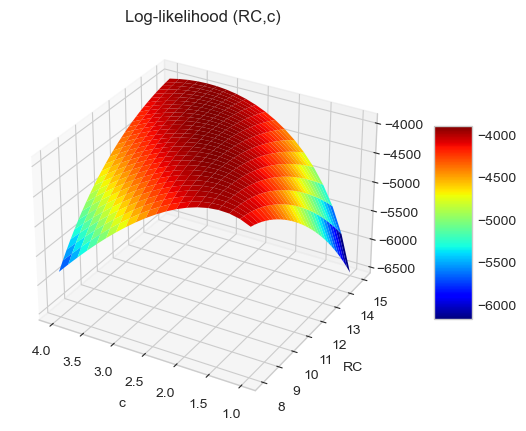

In [4]:
# plot figure in three dimensions
from mpl_toolkits.mplot3d import Axes3D
from matplotlib import cm
plt.style.use('seaborn-whitegrid')


fig = plt.figure(figsize=(10,5))
ax = fig.add_subplot(1,1,1,projection='3d')

# Make data.
X, Y = np.meshgrid(c, RC)

# Plot the surface.
surf = ax.plot_surface(X, Y, log_lik, cmap=cm.jet)

# Customize the axis.
ax.set_xlabel(f'c')
ax.set_ylabel(f'RC')
ax.set_title(f'Log-likelihood (RC,c)')
ax.invert_xaxis()

# Add a color bar which maps values to colors.
fig.colorbar(surf, shrink=0.5, aspect=5)

plt.show()

#### 3. Estimate the model, do you get the correct estimates?

In [ ]:

import time
t0 = time.time()
theta0 = [0,0]

# args for nfxp estimate
#solver.max_fxpiter = 1
nfxp_model, optim_res, pnames, theta_hat, Avar, converged=estimate.estimate(model, solver,data,theta0=theta0, twostep=0)

t1 = time.time()
time = t1-t0

# Print the result
print(f'Structual estimation using busdata from Rust(1987)')
print(f'Beta        = {model.beta:.4f}')
print(f'n           = {model.n}')
print(f'Sample size = {samplesize}\n \n')

print(f'Parameters     Estimates    s.e. ') 
print(f'{pnames[0]}             {theta_hat[0]:.4f}     {np.sqrt(Avar[0,0]):.4f} ')
print(f'{pnames[1]}              {theta_hat[1]:.4f}     {np.sqrt(Avar[1,1]):.4f} \n ')
print(f'{pnames[2]}(1)           {theta_hat[2]:.4f}     {np.sqrt(Avar[2,2]):.4f}  ')
print(f'{pnames[2]}(2)           {theta_hat[3]:.4f}     {np.sqrt(Avar[3,3]):.4f}  ')
print(f'{pnames[2]}(3)           {theta_hat[4]:.4f}     {np.sqrt(Avar[4,4]):.4f}  ')
print(f'{pnames[2]}(4)           {theta_hat[5]:.4f}     {np.sqrt(Avar[5,5]):.4f}  \n')


print(f'Log-likelihood {-optim_res.fun*samplesize:.2f}') 
print(f'runtime (seconds) {time:.4f}')
print(f'The model converged: {converged}')

Structual estimation using busdata from Rust(1987)
Beta        = 0.9999
n           = 175
Sample size = 59500
 

Parameters     Estimates    s.e. 
RC             11.8372     0.3274 
c              2.5056     0.1062 
 
p(1)           0.0933     0.0012  
p(2)           0.4469     0.0023  
p(3)           0.4463     0.0023  
p(4)           0.0132     0.0005  

Log-likelihood -63435.28
runtime (seconds) 0.7398
The model converged: True


a) Try changing the starting values, does the model converges?

In [ ]:
# a) hard to judge correctness based on visual inspection, but seems about right. Some changes in the initial values do not affect convergence, but if theta0 is very
#    far away from the optimum, the model does not converge. Also, with a very big initial value for c, the model tells that it converges, but with really crazy parameters
#    in the magnitude 50 for RC and c. 

#### 4. What happen if you change the maximum number of Newton-Kantorovich iterations to 1? 
Do we get convergence? Do the estimates seem right? 


In [ ]:
# Yes and yes. Perhaps it shouldn't?